I will train a model so that we get better readings on the players than what was previously inferenced

Imports

imports are placed here but once again we have that _patched_torch_load() function here to set that weights_only=False for that pickling error we were getting with pytorch since they changed the default of weights_only=True

In [2]:
# Fix for PyTorch 2.6: Patch torch.load to allow YOLO model loading
import torch
import torch.serialization

# Store original torch.load
_original_torch_load = torch.load

# Create a wrapper that sets weights_only=False for YOLO model files
def _patched_torch_load(f, map_location=None, pickle_module=None, weights_only=None, **kwargs):
    # Always set weights_only=False for YOLO compatibility
    # This allows loading custom YOLO classes that aren't in safe globals
    weights_only = False
    return _original_torch_load(f, map_location=map_location, pickle_module=pickle_module, weights_only=weights_only, **kwargs)

# Patch torch.load
torch.load = _patched_torch_load

from ultralytics import YOLO

Checking if GPU is being used

We want to make sure we are using the GPU and not the CPU. In the case of us having multiple GPUs we want to make sure we are using the right one. This is something I had CLAUDE help me type up so that I could make sure it wasnt my CPU being used 

In [3]:
# Check PyTorch CUDA availability
print("=" * 50)
print("GPU/Device Check")
print("=" * 50)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"CUDA device count: {torch.cuda.device_count()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"Current device: cuda:0")
    print("✅ GPU is available and will be used for training!")
else:
    print("Current device: CPU")
    print("⚠️  WARNING: Using CPU - training will be much slower!")
    print("💡 Tip: Make sure you have CUDA-enabled PyTorch installed if you have an NVIDIA GPU")

print("\n" + "=" * 50)
print("Ultralytics YOLO Device Check")
print("=" * 50)
# Check what device YOLO will use
try:
    model_check = YOLO("yolov8n.pt")
    device = next(model_check.model.parameters()).device
    print(f"YOLO model device: {device}")
    if str(device) == "cpu":
        print("⚠️  YOLO is using CPU - check if GPU is properly configured")
    else:
        print(f"✅ YOLO will use: {device}")
except Exception as e:
    print(f"⚠️  Could not check YOLO device: {e}")
print("=" * 50)


GPU/Device Check
PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
CUDA device count: 1
GPU Name: NVIDIA GeForce RTX 2060
GPU Memory: 6.00 GB
Current device: cuda:0
✅ GPU is available and will be used for training!

Ultralytics YOLO Device Check
YOLO model device: cpu
⚠️  YOLO is using CPU - check if GPU is properly configured


Loading and training the model

Here we are fine tuning that base yolov8n.pt model we inferenced previously. We have our own dataset we are using for the fine tune. I am going to explain all the hyperparameters for the train:

epochs = 100: this is how many times are we looping through the data in training it. A good analogy is a count for how many times you reread lecture before you walked into the exam. The epoch is basically how many times it reread your data before it ended its studying

patience = 15: we want to end the train early if we arent seeing improvement. The patience is to stop if we dont see noticeable improvements for 15 epochs. We dont want to overfit our model

lr0=0.001: This is really important. The learning rate is basically, after every epoch how much do we want to increase or decrease the weights to get to the lowest loss function. The learning rate value is how much we trust how much the gradient calculation says we need to increase or decrease the weight. So if the gradient said, increase the weight of this feature by 5, the learning rate0 would do .001*5 = .05 is how much we are actually going to increase the weight. We normally want learning rate to be higher in lower epochs and higher as we get higher in our epochs. somethings a learning rate scheduler is used to do that. 

device=0: we are setting which device (cpu or different gpus) for this. setting to 0 is us using our GPU

batch = 16: The gradient is averaged over the batch size and then after each batch size (16 in our case) it tells the model how much to alter its weights to try and reach the point where the loss function is lowest. Remember, that if its over a smaller batch will allow for more weight updates per epoch which will allow it to bypass local minima

pretrained=true: uses pretrained weights which is something we want to do because we want to use it as a base

optimizer = AdamW 

for the most part the formula is:

Weight(new) = weight(old) - (learningrate * Optimizer output)

There is a lot to this and this is a VERY important step in the training process

first off, the gradient is how much the loss function changes based on changes in the parameters of the model. Gradient = (delta of loss function / delta of weights )

second, the loss function is a comparison between the correct results and the estimated results and how far off our estimated results are from the correct results

the optimizer looks at the gradient then changes the parameters to try and "hopefully" reduce the loss function as much as possible. There have been multiple different optimizers that look at things a bit differently to try and make that determination. We chose Adam but there are other ones to be looked at:

1- Stochastic Gradient Descent: is the original optimizer it calculates the gradient then takes a step in that direction. It has the same learning rate for all parameters

weight(new) = weight(old) - learningrate * gradient

2- Stochastic gradient descent with momentum: adds the memory of previous gradients to the calculation which is utilized as a velocity function. It builds up speed when gradients point the same way and dampens oscillations but still has the same learning rate for all parameters

velocity = β × velocity + gradient
weight = weight - learning_rate × velocity

3- RMSPROP = It allows the learning rate to change for different parameters in sync. It also looks at the variance in the previous gradients and uses that to take confident larger steps or less confident smaller ones.

v = β*v + (1-β) * gradient^2 
note: β is a smoothing factor (decay factor) which controls how many previous gradients we remember in this calcualtion 1 / (1- β). ex: β = .99 (window of 100), β = .9 (window of 10)

weight(new) = weight(old) - learningrate * gradient / (squareroot(V)+ e)

4- Adam = uses the variance and the momentum - basically combining SGD with RMSPROP. Momentum looks at a window of past gradients and sees what direction they have been going to determine if it should go in that direction or not. Variance looks at how much variance has been in a window of past gradients and determines if it should take a small or big step. 

in both we use the decay factor β₁ to determine if we are looking at a large window or small window of previous gradients. a large window causes deviations in the most recent gradient to matter less while the opposite is true. 
m = β₁* m + (1-β₁)*gradient

we square the gradiant in the v calculation because we want to remove negative signs and see how large the deviation in the gradiants are. we dont care about the direction. Only magnitude matters
v= β₁*variance + (1-β₁) * gradiant^2 



DURING THE TRAIN RUN:

During training we notice different parameters changing with every epoch that is run. box_loss, cls_loss, dfl_loss, instance, size

also a validation line which has class, images, instances, P, R, mAP50, mAP50-95.

I want to discuss these because its important we know what these values mean

box_loss: how wrong the bounding box predictions are from the ground truth (lower = better)
cls_loss: how wrong the class predictions are from the ground truth (lower = better)
dfl_loss: I dont really understand this
instance: how many objects were detected in this batch
size: image size

with the validation line:
We go through the validation dataset after every epoch and test how good our model is

P = our precision rating on the validation. When we guess something is the object how often is it truly the object? (true positive / (false positive + true positive))
R = our recall rating on the validation set. How many of the objects are we actually recognizing? is the object popping in front of us and we arent seeing it? (true positive / (false negative + true positive))
mAP50 = our mean average precision at an IoU of 50 (not very strict)
mAP50-95 = or mean average precision which is averaged at IoU values of between 50-95 (much more strict)

In [4]:
# Load pre-trained COCO model for fine-tuning
model = YOLO("yolov8n.pt")

# Fine-tune on custom dataset
# Key parameters for fine-tuning:
# - lr0: Lower learning rate for fine-tuning (0.001 is good, default 0.01 is for training from scratch)
# - device: Explicitly set to use GPU (0) or CPU
# - batch: Adjust based on GPU memory (16 is default, reduce if OOM errors)
# - epochs: Number of training epochs
# - patience: Early stopping patience
# - imgsz: Image size (640 is standard)
results = model.train(
    data="Training_Dataset/data.yaml",
    epochs=100,
    imgsz=640,
    patience=20,
    lr0=0.001,  # Lower learning rate for fine-tuning (10x smaller than default)
    device=0,   # Use GPU 0 (set to 'cpu' if no GPU, or None for auto-detect)
    batch=16,   # Adjust based on GPU memory (reduce if out of memory)
    pretrained=True,  # Use pre-trained weights (default, but explicit is good)
    optimizer='AdamW',  # AdamW often works better for fine-tuning than SGD
    val=True,   # Validate during training
    plots=True, # Generate training plots
    save=True,  # Save checkpoints
)

New https://pypi.org/project/ultralytics/8.3.237 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.234  Python-3.11.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2060, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Training_Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train5, nbs=64, nms=False, o

After finishing the training I want to analyze the training results. First I'm going to take a look at some of the curve graphs

Normalized Confusion Matrix: 
a-Looks like the main thing that is reducing the precision is mixing up the background with the true object being detected.
b-Looks like the recall is pretty good 

F1 Curve - the f1 curve shows the harmonic mean between the recall and the precision. The confidence shows us the confidence score for the detected object. We can see that the f1 curve is at its highest for all classes around .3 confidence score. So that is the optimal confidence score. When we set our confidence score we will most likely set it to that

Seeing what directory we are inside

In [1]:
import os
print(os.getcwd())


d:\Users from C\Users Files 11-10-23\OneDrive\Documents\Soccer_AI_Detection


After training the model lets see if it is able to recognize the picture better


WARNING 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/750) d:\Users from C\Users Files 11-10-23\OneDrive\Documents\Soccer_AI_Detection\input-videos\08fd33_4.mp4: 384x640 (no detections), 92.7ms
video 1/1 (frame 2/750) d:\Users from C\Users Files 11-10-23\OneDrive\Documents\Soccer_AI_Detection\input-videos\08fd33_4.mp4: 384x640 (no detections), 30.5ms
video 1/1 (frame 3/750) d:\Users from C\Users Files 11-10-23\OneDrive\Documents\Soccer_AI_Detection\input-videos\08fd33_4.mp4: 384x640 (no de

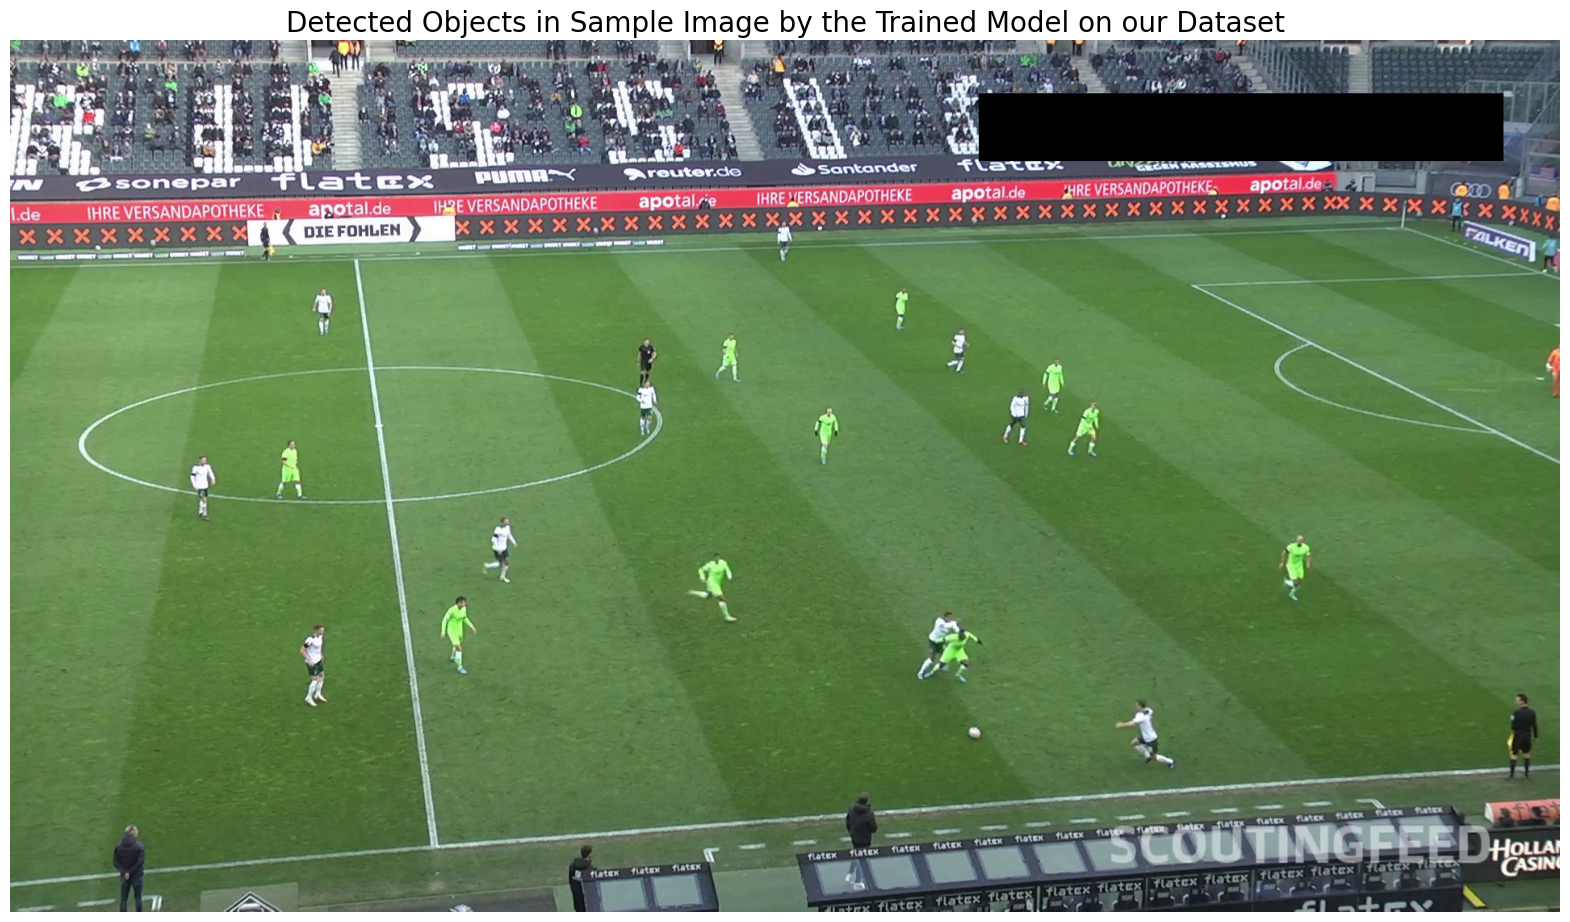

In [7]:
import cv2
import matplotlib.pyplot as plt

model = YOLO("train64/weights/best.pt")
result = model.predict("input-videos/08fd33_4.mp4", stream=False, save=True, save_dir="inference_results/trained_inference/")

sample_image = result[0].plot(line_width=2)
sample_image = cv2.cvtColor(sample_image, cv2.COLOR_RGB2BGR)

# Display annotated image
plt.figure(figsize=(20,15))
plt.imshow(sample_image)
plt.title('Detected Objects in Sample Image by the Trained Model on our Dataset', fontsize=20)
plt.axis('off')
plt.show() # save to disk